# Projekt: Vorhersage der Kundenreaktion im Bankmarketing

In diesem Notebook bauen wir ein Klassifikationsmodell mit Logistic Regression, um vorherzusagen, ob ein Kunde auf eine Marketingkampagne positiv reagiert (`y = yes`) oder nicht.

## Workflow
1. Umgebung vorbereiten
2. Daten laden
3. Grundlegende Bereinigung und Kodierung
4. Features (`X`) und Zielvariable (`y`) definieren
5. Trainings- und Testdaten erstellen
6. Modell trainieren
7. Modell evaluieren
8. Wichtigste Einflussfaktoren interpretieren

Dieses Dokument ist so aufgebaut, dass sowohl der Code als auch die fachliche Begründung klar nachvollziehbar sind.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
 )

import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

print("Setup abgeschlossen - Modellumgebung ist bereit")

Setup abgeschlossen - Modellumgebung ist bereit


## 1) Umgebung und Bibliotheken

Hier werden alle benötigten Bibliotheken importiert:
- `pandas`, `numpy` für Datenverarbeitung
- `train_test_split` für die Aufteilung in Train/Test
- `LogisticRegression` als Modell
- `accuracy_score`, `precision_score`, `recall_score`, `roc_auc_score` für die Bewertung
- `seaborn`, `matplotlib` für Visualisierungen

Zusätzlich werden Anzeigeoptionen für `pandas` gesetzt, damit Tabellen in der Ausgabe besser lesbar sind.

In [3]:
# --- Bank-Marketing-Datensatz laden (Additional Full) ---

import os

dataset_name = "bank-additional-full.csv"
candidate_paths = [
    Path("data/raw/bank_marketing") / dataset_name,
    Path(dataset_name),
]

env_path = os.getenv("BANK_DATA_PATH")
if env_path:
    candidate_paths.append(Path(env_path))

search_roots = [Path.cwd(), Path.home() / "Desktop", Path.home() / "OneDrive"]
for root in search_roots:
    if root.exists():
        match = next(root.rglob(dataset_name), None)
        if match is not None:
            candidate_paths.append(match)

file_path = next((p for p in candidate_paths if p.exists()), None)
if file_path is None:
    raise FileNotFoundError(
        "Datei nicht gefunden. Setze optional die Umgebungsvariable BANK_DATA_PATH "
        "oder lege die Datei im Projektordner ab."
    )

df = pd.read_csv(file_path, sep=';')

print(f"Datensatz wurde erfolgreich geladen: {file_path}")
df.head()

Datensatz wurde erfolgreich geladen: C:\Users\shiva\OneDrive\Desktop\weiter bildung\projekt\ki-marketing-personalisierung-main\data\raw\bank_marketing\bank-additional-full.csv


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 2) Datensatz laden

Der Datensatz `bank-additional-full.csv` wird mit `sep=';'` geladen, da die Datei semikolon-separiert ist.

`df.head()` zeigt die ersten Zeilen zur schnellen Plausibilitätsprüfung.

Empfehlung für eine vollständige Datenprüfung:
- `df.shape` für Dimensionen
- `df.info()` für Datentypen
- `df.isna().sum()` für fehlende Werte

In [4]:
# --- Grundlegende Plausibilitaetspruefung ---

df_model = df.copy()

print("Datensatzgroesse:", df_model.shape)
print("Fehlende Werte je Spalte (Top 10):")
print(df_model.isna().sum().sort_values(ascending=False).head(10))

print("Klassenverteilung in y (roh):")
print(df_model["y"].value_counts(dropna=False))

Datensatzgroesse: (41188, 21)
Fehlende Werte je Spalte (Top 10):
age            0
job            0
marital        0
education      0
default        0
housing        0
loan           0
contact        0
month          0
day_of_week    0
dtype: int64
Klassenverteilung in y (roh):
y
no     36548
yes     4640
Name: count, dtype: int64


## 3) Datenpruefung statt direkter Ordinal-Kodierung

In diesem Schritt wird der Datensatz zunaechst nur geprueft (Groesse, fehlende Werte, Zielverteilung).

Wichtiger methodischer Punkt:
- Eine direkte Umwandlung von Kategorien in Ganzzahlen (`cat.codes`) erzeugt kuenstliche Rangordnungen.
- Fuer nominale Merkmale ist das bei Logistic Regression meist ungeeignet.
- Daher erfolgt die Kodierung spaeter korrekt per One-Hot-Encoding innerhalb der Pipeline.

In [5]:
# --- Schritt 2: Merkmale und Zielvariable definieren ---

# Ziel explizit und reproduzierbar mappen: no=0, yes=1
y = df_model["y"].map({"no": 0, "yes": 1})
if y.isna().any():
    invalid_labels = df_model.loc[y.isna(), "y"].unique()
    raise ValueError(f"Unerwartete Zielklassen gefunden: {invalid_labels}")

X = df_model.drop("y", axis=1)

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Schritt 2 abgeschlossen - X und y sind vorbereitet")
print(f"Anzahl numerischer Features: {len(numeric_features)}")
print(f"Anzahl kategorialer Features: {len(categorical_features)}")
X.head()
y.head()

Schritt 2 abgeschlossen - X und y sind vorbereitet
Anzahl numerischer Features: 10
Anzahl kategorialer Features: 10


0    0
1    0
2    0
3    0
4    0
Name: y, dtype: int64

## 4) Features und Zielvariable definieren

In diesem Schritt werden Eingabemerkmale und Ziel getrennt:
- `X`: alle Praediktoren (alle Spalten ausser `y`)
- `y`: Zielvariable mit expliziter Kodierung `no -> 0`, `yes -> 1`

Zusaetzlich werden Feature-Typen getrennt:
- `numeric_features`: numerische Spalten
- `categorical_features`: kategoriale Spalten

Diese Trennung wird im naechsten Schritt fuer eine saubere Vorverarbeitung in der Pipeline genutzt.

In [6]:
# --- Schritt 3: Aufteilung in Training und Test ---

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Schritt 3 abgeschlossen - Daten in Trainings- und Testmenge aufgeteilt")

Schritt 3 abgeschlossen - Daten in Trainings- und Testmenge aufgeteilt


## 5) Aufteilung in Trainings- und Testdaten

Mit `train_test_split` wird der Datensatz in zwei Teile getrennt:
- Training: zum Lernen der Modellparameter
- Test: zur objektiven Bewertung auf ungesehenen Daten

Wichtige Parameter:
- `test_size=0.25`: 25 % Testanteil
- `random_state=42`: reproduzierbare Ergebnisse
- `stratify=y`: Klassenverhältnis bleibt in beiden Teilmengen erhalten

In [7]:
# --- Schritt 4: Logistic-Regression-Modell trainieren ---

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ],
    remainder="drop",
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("logisticregression", LogisticRegression(max_iter=2000, random_state=42, class_weight="balanced")),
    ]
)

model.fit(X_train, y_train)

print("Schritt 4 abgeschlossen - Pipeline mit One-Hot-Encoding und Logistic Regression wurde trainiert")

Schritt 4 abgeschlossen - Pipeline mit One-Hot-Encoding und Logistic Regression wurde trainiert


## 6) Logistic-Regression-Modell trainieren

Das Modell wird als Pipeline mit typgerechter Vorverarbeitung trainiert:
- numerische Features: `StandardScaler()`
- kategoriale Features: `OneHotEncoder(handle_unknown='ignore')`
- Klassifikator: `LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced')`

Warum diese Struktur?
- One-Hot-Encoding vermeidet falsche Ordnungsannahmen bei Kategorien.
- Skalierung stabilisiert die Optimierung fuer numerische Merkmale.
- `class_weight='balanced'` hilft bei unausgewogener Zielverteilung.
- Die gesamte Verarbeitung bleibt reproduzierbar in einem einzigen Pipeline-Objekt.

Genauigkeit: 0.8645
Praezision: 0.4499
Trefferquote (Recall): 0.9095
Flaeche unter der ROC-Kurve (AUC): 0.9431

Konfusionsmatrix:
[[7847 1290]
 [ 105 1055]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9868    0.8588    0.9184      9137
           1     0.4499    0.9095    0.6020      1160

    accuracy                         0.8645     10297
   macro avg     0.7183    0.8841    0.7602     10297
weighted avg     0.9263    0.8645    0.8827     10297



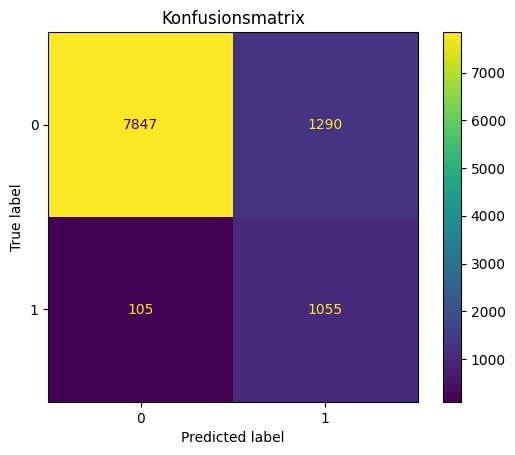

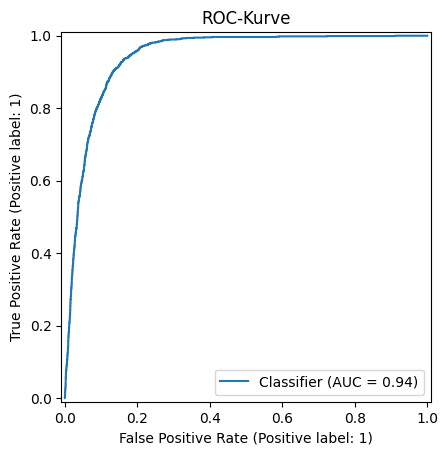

Schritt 5 abgeschlossen - Evaluationsmetriken und Visualisierungen wurden berechnet


In [8]:
# --- Schritt 5: Bewertungsmetriken berechnen ---

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Genauigkeit:", round(accuracy_score(y_test, y_pred), 4))
print("Praezision:", round(precision_score(y_test, y_pred, zero_division=0), 4))
print("Trefferquote (Recall):", round(recall_score(y_test, y_pred, zero_division=0), 4))
print("Flaeche unter der ROC-Kurve (AUC):", round(roc_auc_score(y_test, y_prob), 4))

cm = confusion_matrix(y_test, y_pred)
print("\nKonfusionsmatrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4, zero_division=0))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Konfusionsmatrix")
plt.show()

RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC-Kurve")
plt.show()

print("Schritt 5 abgeschlossen - Evaluationsmetriken und Visualisierungen wurden berechnet")

## 7) Modellbewertung

Es werden mehrere Ausgaben erzeugt:
- `y_pred`: vorhergesagte Klassen
- `y_prob`: Wahrscheinlichkeit fuer die positive Klasse (`yes`)
- Konfusionsmatrix
- Klassifikationsbericht
- ROC-Kurve

Berechnete Kennzahlen:
- **Accuracy**: Anteil korrekter Vorhersagen
- **Precision**: Anteil echter Positiver unter allen positiv vorhergesagten Faellen
- **Recall**: Anteil erkannter Positiver unter allen tatsaechlich positiven Faellen
- **AUC**: Trennfaehigkeit des Modells ueber alle Schwellenwerte hinweg

Interpretation im Geschaeftskontext:
- Fokus auf Precision, wenn Fehlkontakte teuer sind.
- Fokus auf Recall, wenn verpasste Chancen kritisch sind.
- Die Konfusionsmatrix zeigt direkt die Zahl von False Positives und False Negatives.

In [9]:
# --- Schritt 6: Einfluss der Merkmale bestimmen ---

logreg = model.named_steps["logisticregression"]
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

importance = pd.DataFrame({
    "feature": feature_names,
    "coef": logreg.coef_[0],
})
importance["abs_coef"] = importance["coef"].abs()
importance = importance.sort_values(by="abs_coef", ascending=False)

importance.head(20)

,feature,coef,abs_coef
5,num__emp.var.rate,-3.291145,3.291145
1,num__duration,1.806052,1.806052
50,cat__month_mar,1.778190,1.778190
8,num__euribor3m,1.345698,1.345698
6,num__cons.price.idx,1.177668,1.177668
51,cat__month_may,-1.010932,1.010932
49,cat__month_jun,-0.954788,0.954788
46,cat__month_aug,0.870777,0.870777
52,cat__month_nov,-0.836141,0.836141
60,cat__poutcome_failure,-0.505898,0.505898


## 8) Einfluss der Merkmale (Feature Importance)

Die Koeffizienten der Logistic Regression zeigen Richtung und Staerke des Einflusses auf die positive Klasse:
- positiver Koeffizient: erhoeht die Wahrscheinlichkeit fuer `yes`
- negativer Koeffizient: senkt die Wahrscheinlichkeit fuer `yes`

Da One-Hot-Encoding verwendet wird, beziehen sich viele Koeffizienten auf konkrete Kategorien (z. B. `cat__job_admin.`).
Mit der Sortierung nach `abs_coef` werden die staerksten Einflussfaktoren (unabhaengig von der Richtung) sichtbar.

## 9) Fazit und naechste Schritte

### Fazit
Das Modell liefert eine nachvollziehbare erste Grundlage zur Vorhersage von Kundenreaktionen in Marketingkampagnen.
Die ausgegebenen Kennzahlen helfen dabei, die Modellqualitaet aus fachlicher Sicht zu bewerten.

### Naechste Schritte
1. Konfusionsmatrix und ROC-Kurve visualisieren, um die Modellleistung detaillierter zu analysieren.
2. Hyperparameter-Optimierung (z. B. `C`, `solver`) mit Cross-Validation durchfuehren.
3. One-Hot-Encoding und Feature-Skalierung testen, um Robustheit und Interpretierbarkeit weiter zu verbessern.
4. Das trainierte Modell speichern (z. B. mit `joblib`), um es spaeter in einer Anwendung wiederzuverwenden.